In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from msfm.utils import prior, parameters, files, logger, observation, scales
from msi.utils import preprocessing, plotting

In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

### v10

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# # params = ["Om", "s8"]

In [5]:
# with_lensing = False
# with_clustering = True
# # params = ["Om", "s8", "w0", "bg", "n_bg"]
# params = ["Om", "s8"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

In [7]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v10/cls"

In [8]:
# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 50_000
# n_steps = 100_000
# cosine_decay = False
# # cosine_decay = True

# # label = f"lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize},pca={pca_components},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}"

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"

# # file_label = "high_noise"
# # file_label = "no_noise"
# # file_label = "legacy"
# # file_label = "legacy,fixed_binning"
# # file_label = "legacy,l_min=0"
# # file_label = "high_noise"
# # file_label = "no_ell_in_bins_[0,10]"
# # file_label = "no_ell_in_bins_[:8]"
# # file_label = "no_ell_in_bins_[:2]"
# # file_label = "no_ell_in_bins_[-8:]"
# # file_label = "standard"
# # file_label = "legacy,corrected"
# # file_label = "legacy,corrected,l_min"
# # file_label = "default,1%noise"
# # file_label = "10%noise"
# # file_label = "default"
# # file_label = "default,1%noise"
# # file_label = "default,10%noise"
# # file_label = "default,naive_noise"
# # file_label = "sanity_check_2"
# # file_label = "default,from_maps"

# # file_label = "default,new"

# # file_label = "z_consistency,auto"
# # file_label = "z_consistency,26"
# # file_label = "z_consistency,30"
# # file_label = "z_consistency,33"
# # file_label = "z_consistency,35"

# file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# file_label += "_flock"
# # file_label += "_octant"

# # file_label = "hard_cut"
# # file_label = "smoothing_big,noise_small"
# # file_label = "smoothing_small,noise_big"

# label = os.path.join(label, file_label)
# loss = "mutual_info"
# pred_file = os.path.join(out_dir, loss, label, "preds.h5")

### v11

In [9]:
with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# params = ["Om", "s8"]

In [10]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [11]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

In [12]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
out_dir = "/pscratch/sd/a/athomsen/run_files/v11/cls"

n_params = len(params)
apply_log = True
standardize = False
pca_components = None
# n_steps = 50_000
n_steps = 100_000
cosine_decay = False

label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"
# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

file_label = "16mpc"
# file_label = "20mpc"
# file_label = "24mpc"
# file_label = "28mpc"
# file_label += "octant"

file_label += "_" + str(params).replace(" ", "").replace("'", "")

label = os.path.join(label, file_label)
loss = "mutual_info"

pred_file = os.path.join(out_dir, loss, label, "preds.h5")

### v12

In [13]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

In [14]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [15]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [16]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v12/cls"

# # file_label = "16mpc"
# file_label = "/20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label += "octant"
# # file_label += "_no_cross_z"

# n_params = len(params)
# apply_log = True
# standardize = False

# pca_components = None

# # n_steps = 50_000
# n_steps = 100_000
# # n_steps = 200_000
# cosine_decay = False
# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"
# label += file_label
# loss = "mutual_info"
# pred_file = os.path.join(out_dir, loss, label, "preds.h5")

# # label = f"cca/lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize}"
# # label = os.path.join(label, file_label)
# # pred_file = os.path.join(out_dir, label, "preds.h5")

In [17]:
params_indices = [params.index(param) for param in ["Om", "s8", "Aia"]]

In [18]:
params_indices

[0, 1, 3]

In [20]:
def try_mock(f, mock):
    try:
        pred = f[f"mocks/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
print(f"Read from {pred_file}")

new_params = ["Om", "s8", "Aia"]
grid_cosmos = grid_cosmos[:,[params.index(param) for param in new_params]]
params = new_params

# # restrict the parameters the flow is aware of
# # params = ["Om", "s8"]
# params = ["Om", "s8", "w0"]
# # params = ["Om", "s8", "w0", "Aia"]
# # params = ["Om", "s8", "w0", "Aia", "n_Aia"]

# params = ["Om", "s8", "Aia"]


# if params == ["Om", "s8"]:
#     grid_cosmos = grid_cosmos[:,:2]
# if params == ["Om", "s8", "w0"]:
#     grid_cosmos = grid_cosmos[:,:3]
    
# if params == ["Om", "s8", "w0", "Aia"]:
#     grid_cosmos = grid_cosmos[:,:4]
# if params == ["Om", "s8", "w0", "Aia", "n_Aia"]:
#     grid_cosmos = grid_cosmos[:,:5]
# if params == ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]:
#     grid_cosmos = grid_cosmos[:,:6]

print(grid_preds.shape)
print(grid_cosmos.shape)

There is no Buzzard mock in the file
There is no Buzzard_mocked_DNF mock in the file
There is no Cardinal mock in the file
There is no MICE mock in the file
There is no Euclid mock in the file
Read from /pscratch/sd/a/athomsen/run_files/v11/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=100000/16mpc_[Om,s8,w0,Aia,n_Aia,bta]/preds.h5
(200000, 6)
(200000, 3)


# normalizing flow $p(x | \theta)$

### initialization

In [22]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 64

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=128,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=x_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=512,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# # transform = architecture.get_lipschitz_transform(
# #     feature_dim=x_dim,
# #     context_embedding_dim=context_embedding_dim,
# #     n_layers=5,
# #     hidden_dim=128,
# # )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     label=label,
#     # label=label + "_longer_chain",
#     # label=label + "_longer_training",
#     # label=label + "_training_1",
#     load_existing=False,
#     # load_existing=True,
# )

In [23]:
# default

# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    # label=label,
    # label=label + "_lipschitz",
    label=label + "_" + str(params).replace(" ", "").replace("'", ""),
    # label=label + "_" + str(params).replace(" ", "").replace("'", "") + "_tight_gaussian_prior",
    # label=label + "_" + str(params).replace(" ", "").replace("'", "") + "_lipschitz",
    # label=label + "_baseline",
    # load_existing=False,
    load_existing=True,
)

24-12-03 09:00:46 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=100000/16mpc_[Om,s8,w0,Aia,n_Aia,bta]_[Om,s8,Aia]/likelihood_flow 
24-12-03 09:00:46 likelihood_f INF   Initialized the normalizing flow 
24-12-03 09:00:46 likelihood_f INF   Running on device cuda with default float torch.float32 
24-12-03 09:00:46 likelihood_f WAR   Could not load the model from /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=100000/16mpc_[Om,s8,w0,Aia,n_Aia,bta]_[Om,s8,Aia]/likelihood_flow/likelihood_flow.pt 


### training

In [24]:
# default
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=10_000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    scheduler_kwargs={"eta_min": 1e-5},
    # early stopping
    n_patience_epochs=None,
    min_delta=1e-5,
    save_model=True,
)

24-12-03 09:00:53 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
  9%|██▌                         |   | 9/100 [00:25<04:14,  2.79s/it]         lr: 9.80E-04, train: -0.73, vali: -1.04: 


KeyboardInterrupt: 

In [ ]:
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=300,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# likelihood Flow $p(\theta|x)$

### architecture

In [ ]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 32

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=64,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=theta_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     # hidden_dim=256,
#     hidden_dim=512,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     label=label + "_posterior",
#     # load_existing=False,
#     load_existing=True,
# )

### training

In [ ]:
# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_cosmos,
#     theta=grid_preds,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model

In [ ]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_preds.shape[-1],
#     n_theta=grid_cosmos.shape[1],
#     n_gaussians=4,
#     n_units=256,
#     n_layers=4,
#     activation="relu",
#     dropout_rate=0.1,
# )

# model = LikelihoodGMM(
#     params, 
#     conf,
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     load_existing=False,
# )

In [ ]:
# # n_cosmos = file_dict["grid/pred"].shape[0]
# # n_examples = grid_preds.shape[0]
# # # such that GPU utilization is maximized, but not larger
# # batch_size = 8 * n_cosmos
# # print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")
# batch_size = 10_000

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [ ]:
# # v11 and v12
# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     n_cosmos=10_000,
#     do_hist=False,
#     do_dlss=False,
#     do_eecp=True,
#     do_tarp=True,
# )

In [ ]:
# # this only works for v10
# unique_cosmos, inverse_indices = np.unique(grid_cosmos, axis=0, return_inverse=True)
# n_unique_cosmos = unique_cosmos.shape[0]
# n_examples_per_cosmo = int(grid_cosmos.shape[0]//n_unique_cosmos)

# grid_preds_per_cosmo = np.zeros((n_unique_cosmos, n_examples_per_cosmo, grid_preds.shape[1]))
# for i, unique_val in tqdm(enumerate(unique_cosmos)):
#     matching_indices = np.where(inverse_indices == i)[0]
#     grid_preds_per_cosmo[i, :len(matching_indices)] = grid_preds[matching_indices]

# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds_per_cosmo,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=unique_cosmos,
#     n_samples=100,
#     do_hist=True,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

In [ ]:
# n_examples = 10_000
# _ = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=grid_preds[:n_examples,np.newaxis,:], 
#     grid_cosmos=grid_cosmos[:n_examples,:],
#     n_samples=10,
#     do_hist=False,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

# observation

CosmoGrid internal

In [ ]:
obs_dict = {}
n_examples = 16
i_examples = 0
range_examples = range(i_examples*n_examples, (i_examples+1)*n_examples)

# for i_fidu in range(n_examples):
#     obs_dict[f"fiducial_{i_fidu}"] = {
#         "pred": fidu_preds[i_fidu], 
#         "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#     }

obs_dict[f"fiducial_mean"] = {
    "pred": np.mean(fidu_preds[range_examples], axis=0),
    "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
}

obs_dict[f"fiducial_mean_all"] = {
    "pred": np.mean(fidu_preds, axis=0),
    "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
}

obs_dict[f"fiducial_stack"] = {
    "pred": np.stack([fidu_preds[i] for i in range_examples], axis=0), 
    "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
}

# obs_dict[f"fiducial_median"] = {
#     "pred": np.median(fidu_preds, axis=0),
#     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# }

# i_grid = 0
# for i_grid in range(n_examples):
#     obs_dict[f"grid_{i_grid}"] = {
#         "pred": grid_preds[i_grid],
#         "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     }

# obs_dict[f"grid_{i_grid}_mean"] = {
#     "pred": np.mean(grid_preds[:80], axis=0),
#     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
# }

# for i in range(5):
#     grid_selected = grid_preds[i*80:(i+1)*80]
#     cosmos_selected = grid_cosmos[i*80:(i+1)*80]
#     point = {str(param): value for param, value in zip(params, cosmos_selected[0])}
#     print(i, point)
    
#     # for j in range(n_examples):
#     #     obs_dict[f"grid_{i},{j}"] = {
#     #         "pred": grid_selected[j],
#     #         "point": point,
#     #     }
        
#     obs_dict[f"grid_{i}_stack"] = {
#         "pred": np.stack([grid_selected[j] for j in range(n_examples)], axis=0), 
#         "point": point,
#     }

#     obs_dict[f"grid_{i}_mean"] = {
#         "pred": np.mean(grid_selected[:n_examples], axis=0),
#         "point": point,
#     }

DES footprint

In [ ]:
# # obs_dict = {}

# # bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan, "qbg1": np.nan, "qbg2": np.nan, "qbg3": np.nan, "qbg4": np.nan}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(buzzard_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# obs_dict["Cardinal"] = {
#     "pred": np.squeeze(cardinal_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

In [ ]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# for i, buzzard_flock_label in enumerate(buzzard_flock_labels):
#     buzzard = np.squeeze(file_dict[f"mocks/pred/{buzzard_flock_label}"])
#     buzzard_flock_preds.append(buzzard)
    
#     # obs_dict[f"Buzzard_{i}"] = {
#     #     "pred": buzzard,
#     #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#     # }
        
# # buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# # obs_dict["Buzzard_flock_stack"] = {
# #     "pred": buzzard_flock_preds,
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# # }

# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_mean"] = {
#     "pred": buzzard_flock_mean,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

Octant footprint

In [ ]:
# obs_dict["MICE"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/MICE"]),
#     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

# obs_dict["Euclid"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Euclid"]),
#     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

### MCMC and plotting

In [ ]:
# extra_label = ""
extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks_w0wide"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks_w0wide"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks_s8_narrow"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_sanity"

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    # print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_burnin_steps=1000,
        n_samples=1024*1000,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
    )

### sample the posterior directly

In [ ]:
# extra_label = ""

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     # posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=10_000, batch_size=None, return_numpy=True)
#     posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=100_000, batch_size=None, return_numpy=True)
#     posterior_samples = np.squeeze(posterior_samples)
    
#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )
    
#     samples_file = os.path.join(model.model_dir, f"chain_{key}.npy")
#     print(samples_file)
#     np.save(samples_file, posterior_samples)

In [ ]:
# extra_label = "_16_mocks"

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     posterior_samples = model.sample_posterior(
#         obs_dict[key]["pred"],
#         label=key+extra_label,
#         n_walkers=1024,
#         n_burnin_steps=500,
#         n_samples=1024*500,
#     )

#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )

#     # model.plot_contours(
#     #     posterior_samples,
#     #     obs_point=obs_dict[key]["point"],
#     #     obs_label=key,
#     #     label=key+extra_label,
#     #     with_des_chain=False,
#     # )

# old

In [21]:
import numpy as np
from msfm.utils import prior, files, parameters
from trianglechain import TriangleChain

In [5]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
params = ["Om", "s8", "w0"]
priors = parameters.get_prior_intervals(params, conf)
samples = np.random.uniform(low=priors[:,0], high=priors[:,1], size=(1000, 3))
samples = samples[prior.in_grid_prior(samples, conf=conf, params=params)]

In [63]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
params = ["Om", "s8", "w0"]
priors = parameters.get_prior_intervals(params, conf)

samples = np.random.uniform(low=priors[:,0], high=priors[:,1], size=(10_000, 3))
samples_in_prior = samples[prior.in_grid_prior(samples, conf=conf, params=params)]

  0%|          | 0/3 [00:00<?, ?it/s]

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: ylabel='Om'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='s8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Om', ylabel='w0'>, <Axes: xlabel='s8'>,
         <Axes: xlabel='w0'>]], dtype=object))

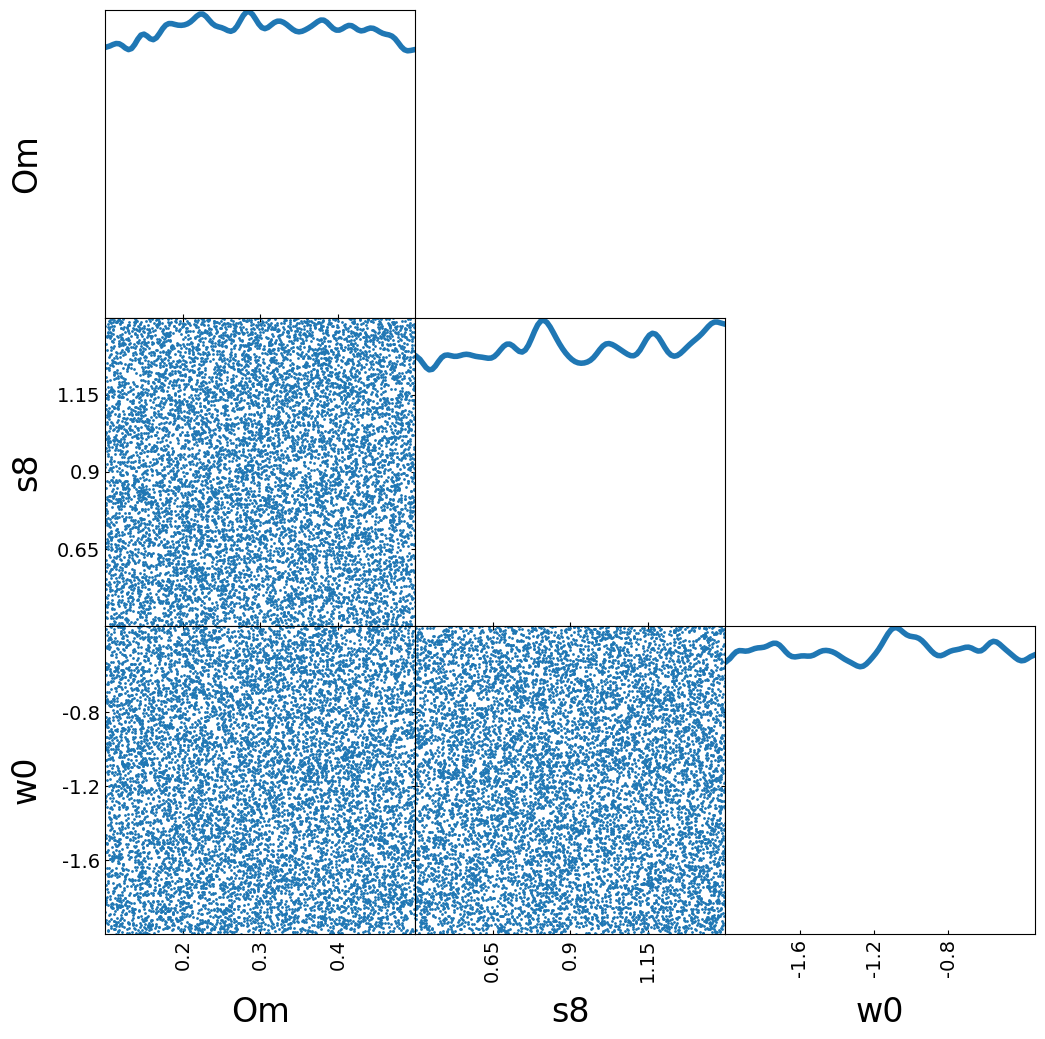

In [65]:
tri = TriangleChain(
    ranges=priors,
    labels=params,
    scatter_kwargs={"s": 1},
)

tri.scatter(
    samples,
)

  0%|          | 0/3 [00:00<?, ?it/s]

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: ylabel='Om'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='s8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Om', ylabel='w0'>, <Axes: xlabel='s8'>,
         <Axes: xlabel='w0'>]], dtype=object))

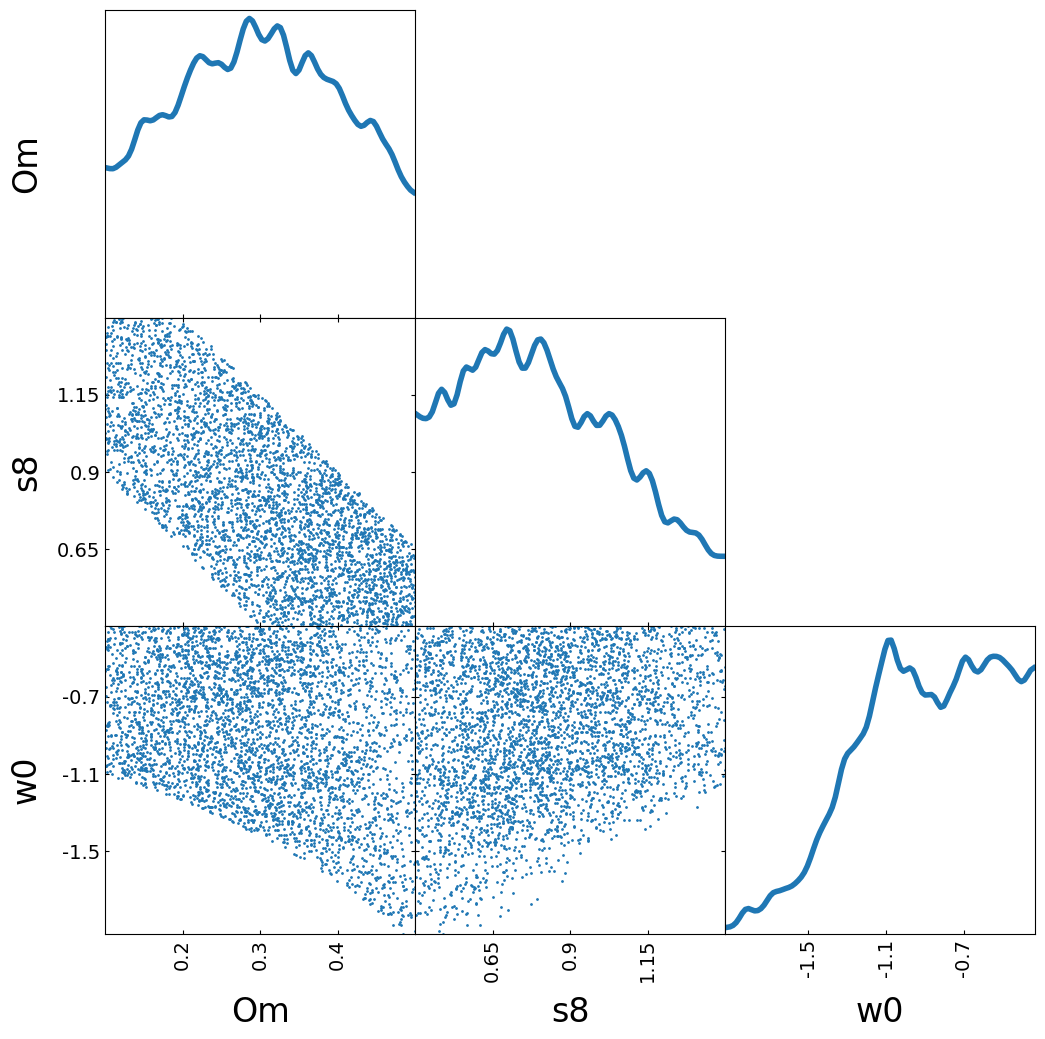

In [66]:
tri = TriangleChain(
    ranges=priors,
    labels=params,
    scatter_kwargs={"s": 1},
)

tri.scatter(
    samples_in_prior,
)

In [ ]:
from scipy.stats import norm
import numpy as np
from msfm.utils import prior, parameters

In [ ]:
temp = prior.gaussian_prior(grid_cosmos[::80][:10], conf=conf, params=params)

In [ ]:
temp = prior.gaussian_prior(grid_cosmos[::80][:10], conf=conf, params=["Om", "s8", "w0"])

print(temp)

In [ ]:
np.diff(parameters.get_prior_intervals(["Om", "s8"], conf)).shape

In [ ]:
parameters.get_prior_intervals(["Om", "s8"], conf).shape